In [1]:
# Cell 1: Imports and Setup
from transformers import pipeline, GPT2Tokenizer, GPT2LMHeadModel
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import re
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize

# Download required NLTK data
import nltk
nltk.download('punkt')

# Define model path
MODEL_PATH = "/Users/farooqkhan/My Mac/GitHub/LLMs/polymath-1/fine_tuned_model"

# Device setup for MPS (Apple Silicon) or CPU
device = torch.device("cuda" if torch.cuda.is_available() else 
                     "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Define custom metrics for text evaluation
def calculate_text_metrics(generated_text, reference_text=None):
    """
    Calculate various text metrics including lexical diversity and BLEU score if reference is provided
    """
    tokens = word_tokenize(generated_text.lower())
    unique_tokens = set(tokens)
    
    metrics = {
        'length': len(tokens),
        'unique_tokens': len(unique_tokens),
        'lexical_diversity': len(unique_tokens) / len(tokens) if tokens else 0
    }
    
    if reference_text:
        reference_tokens = [word_tokenize(reference_text.lower())]
        bleu_score = sentence_bleu(reference_tokens, tokens)
        metrics['bleu_score'] = bleu_score
        
    return metrics

Using device: mps


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/farooqkhan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Vocabulary Analysis Statistics:
--------------------------------------------------
Number of terms analyzed: 7
Average cosine similarity: 0.579
Standard deviation of similarities: 0.414

Most Similar Term Pairs:
enzyme - superposition: 1.000
ATP - superposition: 1.000
ATP - enzyme: 1.000

Least Similar Term Pairs:
RNA - quantum: 0.138
RNA - H2O: 0.138
RNA - ATP: 0.138

Embedding Statistics:
Average embedding norm: 3.432
Std deviation of norms: 0.533

Embedding Norms by Term:
DNA: 4.176
RNA: 4.366
quantum: 3.097
H2O: 3.097
ATP: 3.097
enzyme: 3.097
superposition: 3.097

PCA Explained Variance Ratio: 0.818, 0.182
Total Variance Explained: 1.000


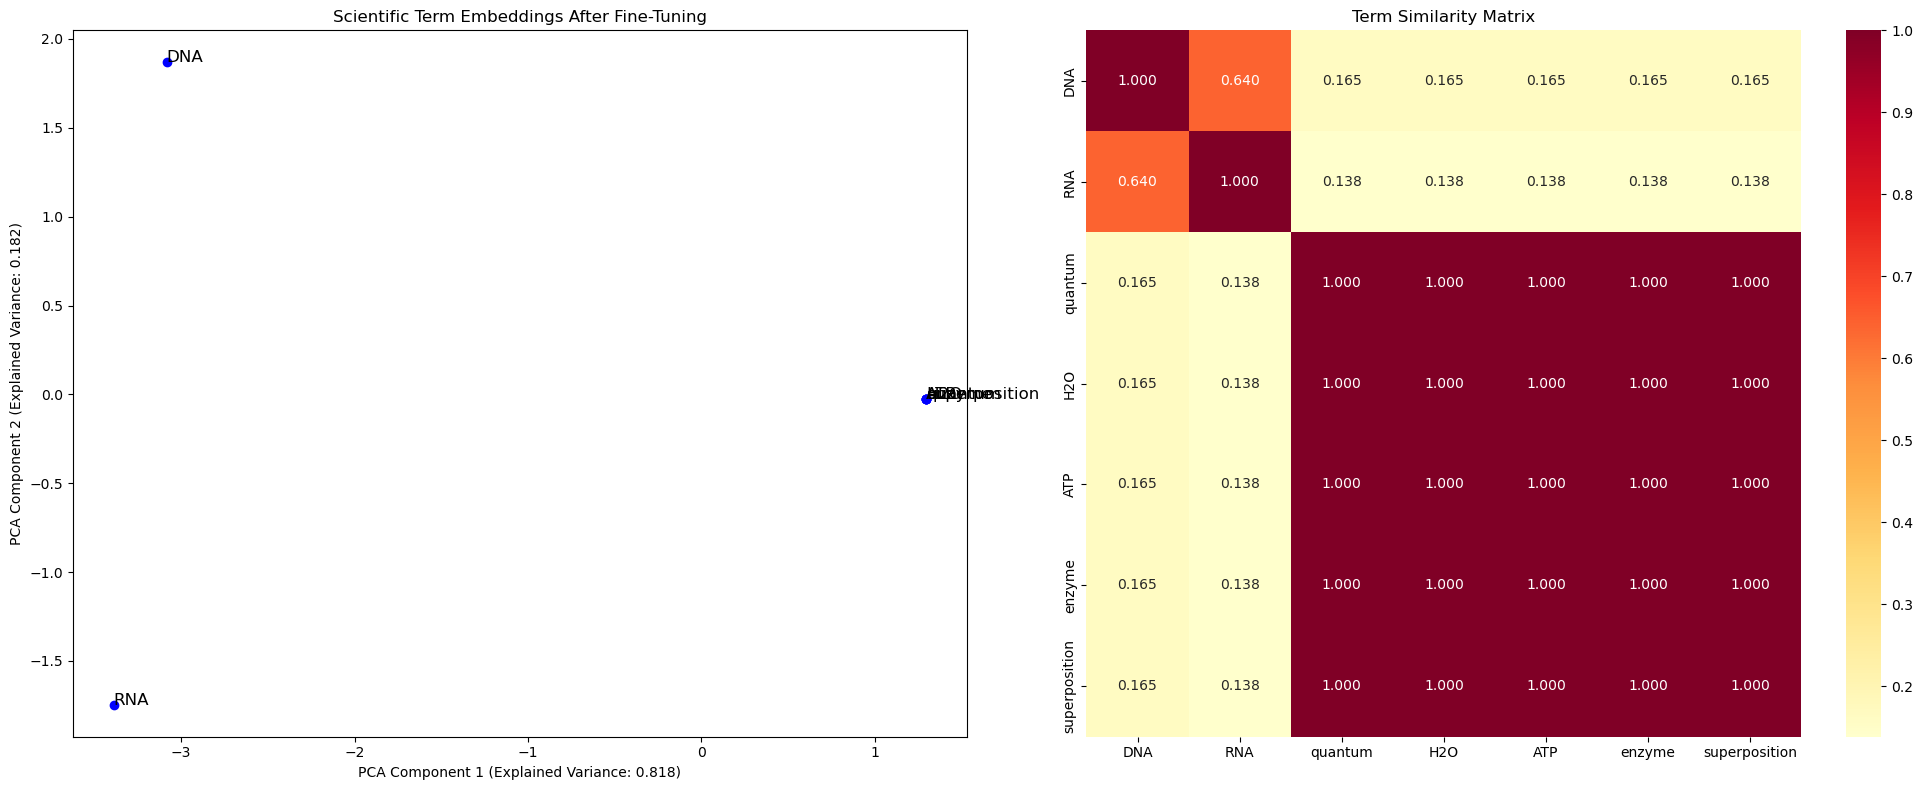


Summary of Term Relationships:
--------------------------------------------------
Terms with highest average similarity to others:
quantum: 0.758
H2O: 0.758
ATP: 0.758
enzyme: 0.758
superposition: 0.758
DNA: 0.352
RNA: 0.333


In [2]:
# Cell 2: Vocabulary Mastery Analysis
def evaluate_vocabulary_mastery(model_path, terms):
    """
    Enhanced vocabulary mastery evaluation with similarity analysis, visualization, and statistics
    """
    model = GPT2LMHeadModel.from_pretrained(model_path)
    tokenizer = GPT2Tokenizer.from_pretrained(model_path)
    
    # Get embeddings
    embeddings = model.transformer.wte.weight.detach().cpu().numpy()
    term_ids = [tokenizer.convert_tokens_to_ids(term) for term in terms 
                if tokenizer.convert_tokens_to_ids(term) is not None]
    term_embeddings = embeddings[term_ids]
    
    # Compute similarity matrix
    similarity_matrix = cosine_similarity(term_embeddings)
    
    # Calculate statistical measures
    avg_similarity = np.mean(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)])
    std_similarity = np.std(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)])
    
    # Find most and least similar term pairs
    pairs = []
    for i in range(len(terms)):
        for j in range(i+1, len(terms)):
            pairs.append((terms[i], terms[j], similarity_matrix[i, j]))
    
    sorted_pairs = sorted(pairs, key=lambda x: x[2])
    least_similar = sorted_pairs[:3]  # Get 3 least similar pairs
    most_similar = sorted_pairs[-3:]  # Get 3 most similar pairs
    
    # Print Statistics
    print("\nVocabulary Analysis Statistics:")
    print("-" * 50)
    print(f"Number of terms analyzed: {len(terms)}")
    print(f"Average cosine similarity: {avg_similarity:.3f}")
    print(f"Standard deviation of similarities: {std_similarity:.3f}")
    print("\nMost Similar Term Pairs:")
    for term1, term2, sim in reversed(most_similar):
        print(f"{term1} - {term2}: {sim:.3f}")
    print("\nLeast Similar Term Pairs:")
    for term1, term2, sim in least_similar:
        print(f"{term1} - {term2}: {sim:.3f}")
    
    # Calculate embedding statistics
    embedding_norms = np.linalg.norm(term_embeddings, axis=1)
    print("\nEmbedding Statistics:")
    print(f"Average embedding norm: {np.mean(embedding_norms):.3f}")
    print(f"Std deviation of norms: {np.std(embedding_norms):.3f}")
    print("\nEmbedding Norms by Term:")
    for term, norm in zip(terms, embedding_norms):
        print(f"{term}: {norm:.3f}")
    
    # Visualize embeddings using PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(term_embeddings)
    
    # Calculate explained variance
    explained_variance = pca.explained_variance_ratio_
    print(f"\nPCA Explained Variance Ratio: {explained_variance[0]:.3f}, {explained_variance[1]:.3f}")
    print(f"Total Variance Explained: {sum(explained_variance):.3f}")
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Scatter plot
    ax1.scatter(reduced[:, 0], reduced[:, 1], color='blue')
    for i, term in enumerate(terms):
        if tokenizer.convert_tokens_to_ids(term) is not None:
            ax1.annotate(term, (reduced[i, 0], reduced[i, 1]), fontsize=12)
    ax1.set_title("Scientific Term Embeddings After Fine-Tuning")
    ax1.set_xlabel(f"PCA Component 1 (Explained Variance: {explained_variance[0]:.3f})")
    ax1.set_ylabel(f"PCA Component 2 (Explained Variance: {explained_variance[1]:.3f})")
    
    # Similarity heatmap
    sns.heatmap(similarity_matrix, annot=True, xticklabels=terms, 
                yticklabels=terms, ax=ax2, cmap='YlOrRd', fmt='.3f')
    ax2.set_title("Term Similarity Matrix")
    
    plt.tight_layout()
    plt.show()
    
    # Return analysis results
    return {
        'reduced_embeddings': reduced,
        'similarity_matrix': similarity_matrix,
        'statistics': {
            'avg_similarity': avg_similarity,
            'std_similarity': std_similarity,
            'embedding_norms': embedding_norms.tolist(),
            'explained_variance': explained_variance.tolist(),
            'most_similar_pairs': most_similar,
            'least_similar_pairs': least_similar
        }
    }

# Terms to evaluate
scientific_terms = ["DNA", "RNA", "quantum", "H2O", "ATP", "enzyme", "superposition"]
results = evaluate_vocabulary_mastery(MODEL_PATH, scientific_terms)

# Additional Analysis Summary
print("\nSummary of Term Relationships:")
print("-" * 50)
print("Terms with highest average similarity to others:")
avg_similarities = results['similarity_matrix'].mean(axis=1)
term_similarities = list(zip(scientific_terms, avg_similarities))
sorted_terms = sorted(term_similarities, key=lambda x: x[1], reverse=True)
for term, avg_sim in sorted_terms:
    print(f"{term}: {avg_sim:.3f}")

In [3]:
# Cell 3: Evaluate Behavioral Shifts and Generalization
def evaluate_behavior_and_generalization(model_path, prompts, max_length=150):
    """
    Evaluate the model's behavior in domain-specific and general contexts.
    """
    generator = pipeline(
        'text-generation',
        model=model_path,
        tokenizer=model_path,
        device=0 if torch.cuda.is_available() else -1,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        repetition_penalty=1.2
    )

    print("Testing model on domain-specific and general prompts...\n")
    
    responses = []
    for prompt in prompts:
        response = generator(
            prompt,
            max_length=max_length,
            num_return_sequences=1,
            pad_token_id=50256,
            truncation=True
        )[0]['generated_text']
        
        # Calculate metrics for the response
        metrics = calculate_text_metrics(response)
        responses.append({
            'prompt': prompt,
            'response': response,
            **metrics  # Unpack metrics into the response dictionary
        })
        
        print(f"Prompt: {prompt}\n{'-' * 50}")
        print(f"Generated Response:\n{response}\n")
        print(f"Response Metrics:")
        print(f"Length: {metrics['length']} tokens")
        print(f"Unique tokens: {metrics['unique_tokens']}")
        print(f"Lexical diversity: {metrics['lexical_diversity']:.3f}")
        print("=" * 80 + "\n")
    
    return responses

# Test prompts
domain_prompts = [
    "Explain the quantum effects on molecular interactions.",
    "Describe the role of mitochondria in energy production.",
    "What are catalysts, and how do they reduce activation energy?",
]
general_prompts = [
    "What is the importance of interdisciplinary research?",
    "What are the main principles of physics?",
    "How does machine learning impact healthcare?"
]

# Run evaluation
print("Domain-Specific Prompts:\n")
domain_responses = evaluate_behavior_and_generalization(MODEL_PATH, domain_prompts)
print("General Prompts:\n")
general_responses = evaluate_behavior_and_generalization(MODEL_PATH, general_prompts)

Domain-Specific Prompts:

Testing model on domain-specific and general prompts...

Prompt: Explain the quantum effects on molecular interactions.
--------------------------------------------------
Generated Response:
Explain the quantum effects on molecular interactions.

Response Metrics:
Length: 8 tokens
Unique tokens: 8
Lexical diversity: 1.000

Prompt: Describe the role of mitochondria in energy production.
--------------------------------------------------
Generated Response:
Describe the role of mitochondria in energy production.
The key question is what should we expect from a cell that has been exposed to low levels (e.g., eukaryotes, neutrinos, etc.) and how this could be achieved using mitochondrial DNA or other nucleotide polymorphisms?

Response Metrics:
Length: 51 tokens
Unique tokens: 47
Lexical diversity: 0.922

Prompt: What are catalysts, and how do they reduce activation energy?
--------------------------------------------------
Generated Response:
What are catalysts, 


Analyzing Domain-Specific Responses:

Domain-Specific Response Summary Statistics:
           length  unique_tokens  lexical_diversity
count    3.000000       3.000000           3.000000
mean    66.333333      61.000000           0.945285
std     67.322606      61.212744           0.047524
min      8.000000       8.000000           0.914286
25%     29.500000      27.500000           0.917927
50%     51.000000      47.000000           0.921569
75%     95.500000      87.500000           0.960784
max    140.000000     128.000000           1.000000


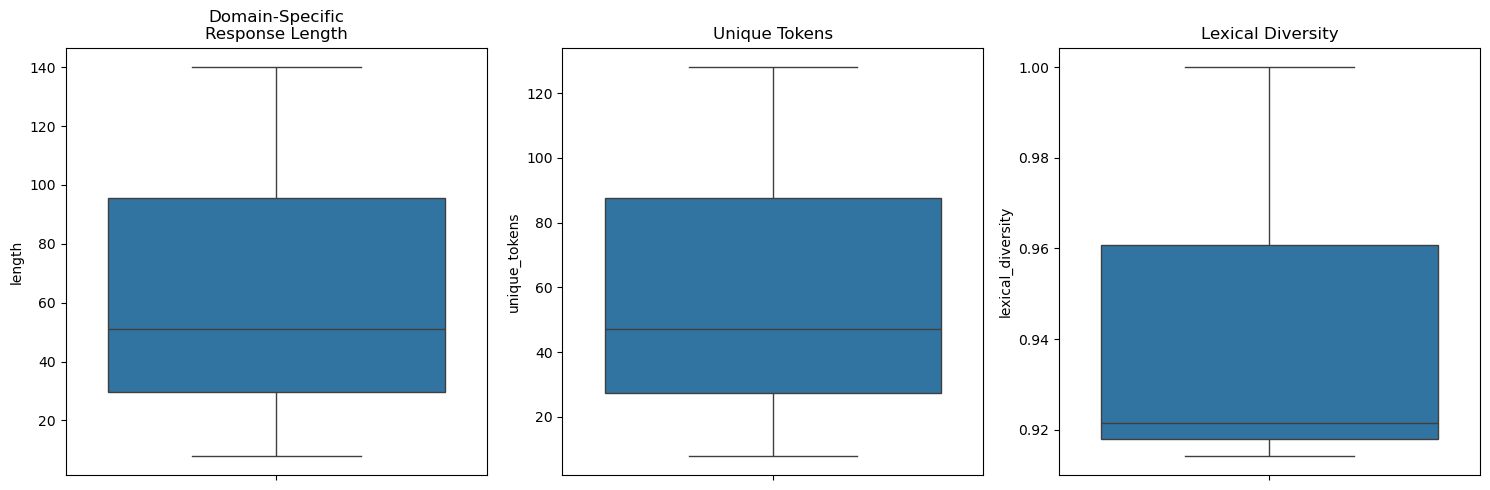


Analyzing General Responses:

General Response Summary Statistics:
           length  unique_tokens  lexical_diversity
count    3.000000       3.000000           3.000000
mean   127.666667     116.333333           0.916771
std     30.924640      24.583192           0.034441
min     92.000000      88.000000           0.895833
25%    118.000000     108.500000           0.896896
50%    144.000000     129.000000           0.897959
75%    145.500000     130.500000           0.927240
max    147.000000     132.000000           0.956522


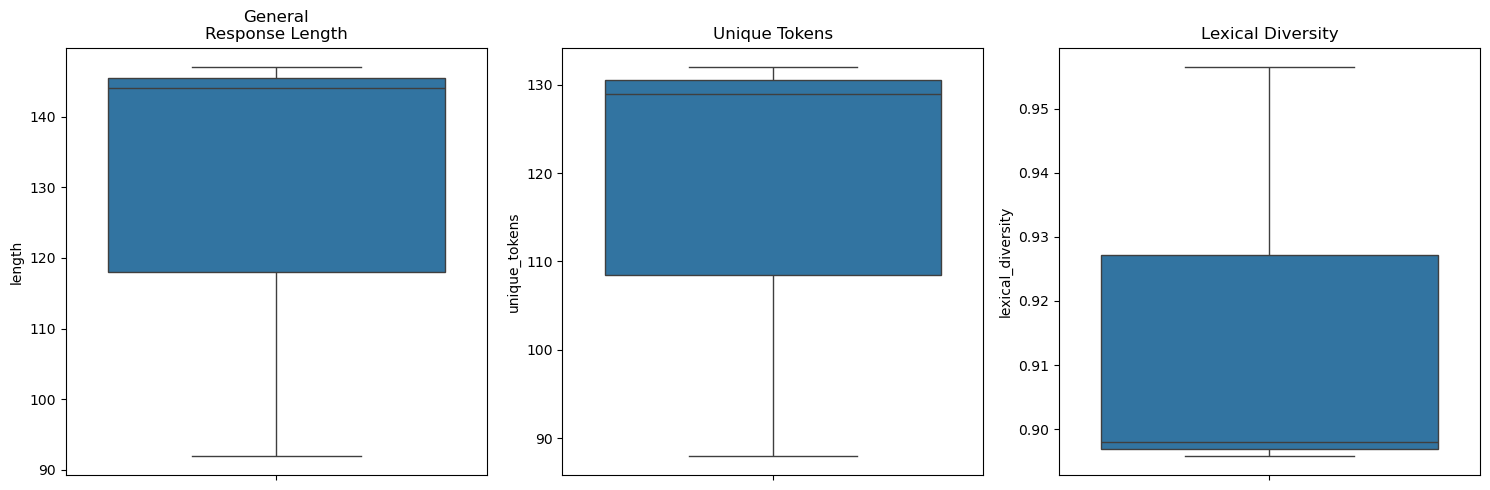

In [4]:
# Cell 4: Response Analysis and Visualization
def analyze_responses(responses, category):
    """
    Analyze and visualize response characteristics
    """
    metrics = {
        'length': [r['length'] for r in responses],
        'unique_tokens': [r['unique_tokens'] for r in responses],
        'lexical_diversity': [r['lexical_diversity'] for r in responses]
    }
    
    df = pd.DataFrame(metrics)
    
    # Calculate summary statistics
    summary = df.describe()
    print(f"\n{category} Response Summary Statistics:")
    print(summary)
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Length distribution
    sns.boxplot(data=df, y='length', ax=axes[0])
    axes[0].set_title(f'{category}\nResponse Length')
    
    # Unique tokens distribution
    sns.boxplot(data=df, y='unique_tokens', ax=axes[1])
    axes[1].set_title('Unique Tokens')
    
    # Lexical diversity distribution
    sns.boxplot(data=df, y='lexical_diversity', ax=axes[2])
    axes[2].set_title('Lexical Diversity')
    
    plt.tight_layout()
    plt.show()
    
    return summary

# Analyze both sets of responses
print("\nAnalyzing Domain-Specific Responses:")
domain_summary = analyze_responses(domain_responses, "Domain-Specific")
print("\nAnalyzing General Responses:")
general_summary = analyze_responses(general_responses, "General")


Domain-Specific Responses:


Calculating perplexity:   0%|          | 0/3 [00:00<?, ?it/s]


Perplexity Analysis:
--------------------------------------------------
Average Perplexity: 84.54
Weighted Perplexity: 31.86
Perplexity Std Dev: 89.08

Per-sample Statistics:
Min Perplexity: 15.37
Max Perplexity: 210.31
Median Perplexity: 27.95


<Figure size 1200x500 with 0 Axes>

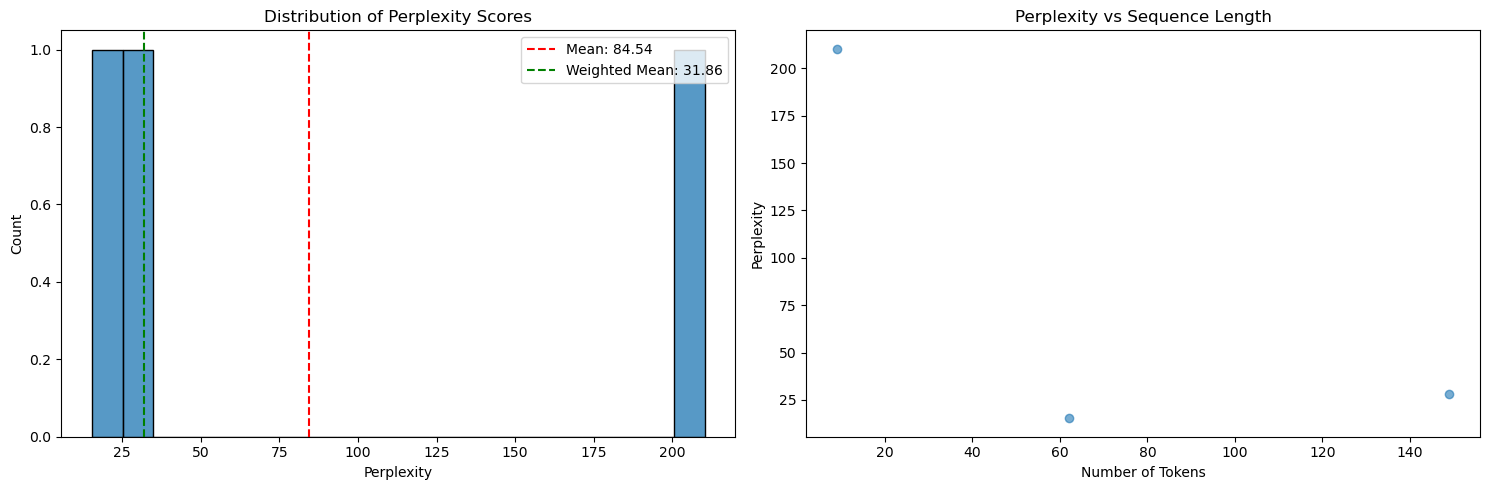


Sample-specific Analysis:
--------------------------------------------------
Top 3 Best Performing Samples (Lowest Perplexity):

Perplexity: 15.37
Sample: Describe the role of mitochondria in energy production.
The key question is what should we expect fr...

Perplexity: 27.95
Sample: What are catalysts, and how do they reduce activation energy?
The key is the activity of different p...

Perplexity: 210.31
Sample: Explain the quantum effects on molecular interactions....

Top 3 Worst Performing Samples (Highest Perplexity):

Perplexity: 15.37
Sample: Describe the role of mitochondria in energy production.
The key question is what should we expect fr...

Perplexity: 27.95
Sample: What are catalysts, and how do they reduce activation energy?
The key is the activity of different p...

Perplexity: 210.31
Sample: Explain the quantum effects on molecular interactions....

General Responses:


Calculating perplexity:   0%|          | 0/3 [00:00<?, ?it/s]


Perplexity Analysis:
--------------------------------------------------
Average Perplexity: 24.46
Weighted Perplexity: 24.30
Perplexity Std Dev: 1.14

Per-sample Statistics:
Min Perplexity: 22.96
Max Perplexity: 25.72
Median Perplexity: 24.70


<Figure size 1200x500 with 0 Axes>

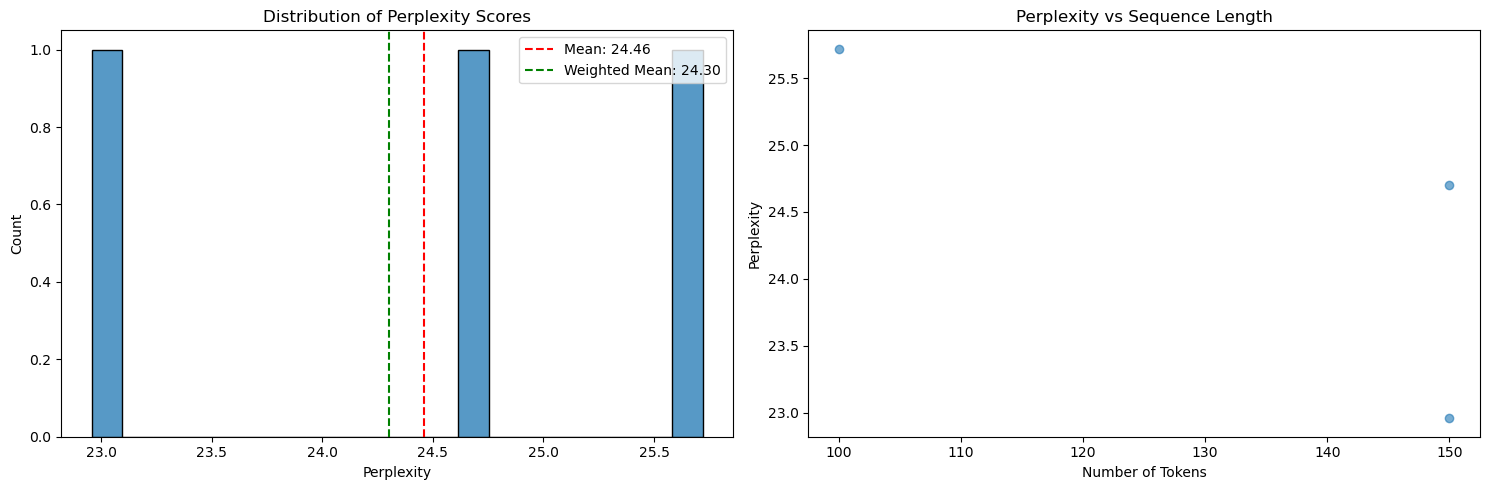


Sample-specific Analysis:
--------------------------------------------------
Top 3 Best Performing Samples (Lowest Perplexity):

Perplexity: 22.96
Sample: What are the main principles of physics?
This is a complex question that needs to be answered. First...

Perplexity: 24.70
Sample: What is the importance of interdisciplinary research?
The most important question I have come to ask...

Perplexity: 25.72
Sample: How does machine learning impact healthcare?
The following analysis is based on a study of 3,000 med...

Top 3 Worst Performing Samples (Highest Perplexity):

Perplexity: 22.96
Sample: What are the main principles of physics?
This is a complex question that needs to be answered. First...

Perplexity: 24.70
Sample: What is the importance of interdisciplinary research?
The most important question I have come to ask...

Perplexity: 25.72
Sample: How does machine learning impact healthcare?
The following analysis is based on a study of 3,000 med...

Domain vs General Comparison:


In [5]:
# Cell 5: Enhanced Perplexity Evaluation
import os
from tqdm.notebook import tqdm
import warnings

def calculate_perplexity(model_path, test_samples):
    """
    Calculate model perplexity on test samples with detailed analysis
    """
    # Set tokenizer parallelism explicitly
    os.environ["TOKENIZERS_PARALLELISM"] = "false"
    
    model = GPT2LMHeadModel.from_pretrained(model_path).to(device)
    tokenizer = GPT2Tokenizer.from_pretrained(model_path)
    
    # Initialize metrics storage
    perplexities = []
    token_counts = []
    losses = []
    
    model.eval()
    with torch.no_grad():
        # Calculate perplexity for each sample
        for sample in tqdm(test_samples, desc="Calculating perplexity", leave=False):
            inputs = tokenizer(sample, return_tensors="pt").to(device)
            outputs = model(**inputs, labels=inputs["input_ids"])
            
            # Calculate per-sample metrics
            loss = outputs.loss.item()
            n_tokens = inputs["input_ids"].size(1)
            perplexity = torch.exp(torch.tensor(loss))
            
            perplexities.append(perplexity.item())
            token_counts.append(n_tokens)
            losses.append(loss)
    
    # Calculate aggregate metrics
    avg_perplexity = np.mean(perplexities)
    weighted_perplexity = np.average(perplexities, weights=token_counts)
    
    # Print detailed analysis
    print("\nPerplexity Analysis:")
    print("-" * 50)
    print(f"Average Perplexity: {avg_perplexity:.2f}")
    print(f"Weighted Perplexity: {weighted_perplexity:.2f}")
    print(f"Perplexity Std Dev: {np.std(perplexities):.2f}")
    print(f"\nPer-sample Statistics:")
    print(f"Min Perplexity: {min(perplexities):.2f}")
    print(f"Max Perplexity: {max(perplexities):.2f}")
    print(f"Median Perplexity: {np.median(perplexities):.2f}")
    
    # Visualize perplexity distribution
    plt.figure(figsize=(12, 5))
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Perplexity distribution
    sns.histplot(perplexities, bins=20, ax=ax1)
    ax1.axvline(avg_perplexity, color='r', linestyle='--', label=f'Mean: {avg_perplexity:.2f}')
    ax1.axvline(weighted_perplexity, color='g', linestyle='--', label=f'Weighted Mean: {weighted_perplexity:.2f}')
    ax1.set_title('Distribution of Perplexity Scores')
    ax1.set_xlabel('Perplexity')
    ax1.set_ylabel('Count')
    ax1.legend()
    
    # Perplexity vs sequence length scatter plot
    ax2.scatter(token_counts, perplexities, alpha=0.6)
    ax2.set_title('Perplexity vs Sequence Length')
    ax2.set_xlabel('Number of Tokens')
    ax2.set_ylabel('Perplexity')
    
    plt.tight_layout()
    plt.show()
    
    # Create detailed results dictionary
    results = {
        'average_perplexity': avg_perplexity,
        'weighted_perplexity': weighted_perplexity,
        'std_dev': np.std(perplexities),
        'min_perplexity': min(perplexities),
        'max_perplexity': max(perplexities),
        'median_perplexity': np.median(perplexities),
        'per_sample': list(zip(test_samples, perplexities, token_counts))
    }
    
    # Print sample-specific analysis
    print("\nSample-specific Analysis:")
    print("-" * 50)
    print("Top 3 Best Performing Samples (Lowest Perplexity):")
    sorted_samples = sorted(zip(test_samples, perplexities), key=lambda x: x[1])
    for sample, perp in sorted_samples[:3]:
        print(f"\nPerplexity: {perp:.2f}")
        print(f"Sample: {sample[:100]}...")
        
    print("\nTop 3 Worst Performing Samples (Highest Perplexity):")
    for sample, perp in sorted_samples[-3:]:
        print(f"\nPerplexity: {perp:.2f}")
        print(f"Sample: {sample[:100]}...")
    
    return results

# Separate domain-specific and general samples
domain_samples = [r['response'] for r in domain_responses]
general_samples = [r['response'] for r in general_responses]

# Calculate perplexity for both sets
print("\nDomain-Specific Responses:")
domain_perplexity_results = calculate_perplexity(MODEL_PATH, domain_samples)

print("\nGeneral Responses:")
general_perplexity_results = calculate_perplexity(MODEL_PATH, general_samples)

# Compare domain-specific vs general performance
comparison_df = pd.DataFrame({
    'Domain-Specific': [domain_perplexity_results['average_perplexity'],
                       domain_perplexity_results['weighted_perplexity'],
                       domain_perplexity_results['std_dev']],
    'General': [general_perplexity_results['average_perplexity'],
                general_perplexity_results['weighted_perplexity'],
                general_perplexity_results['std_dev']]
}, index=['Average Perplexity', 'Weighted Perplexity', 'Standard Deviation'])

print("\nDomain vs General Comparison:")
print(comparison_df.round(2))

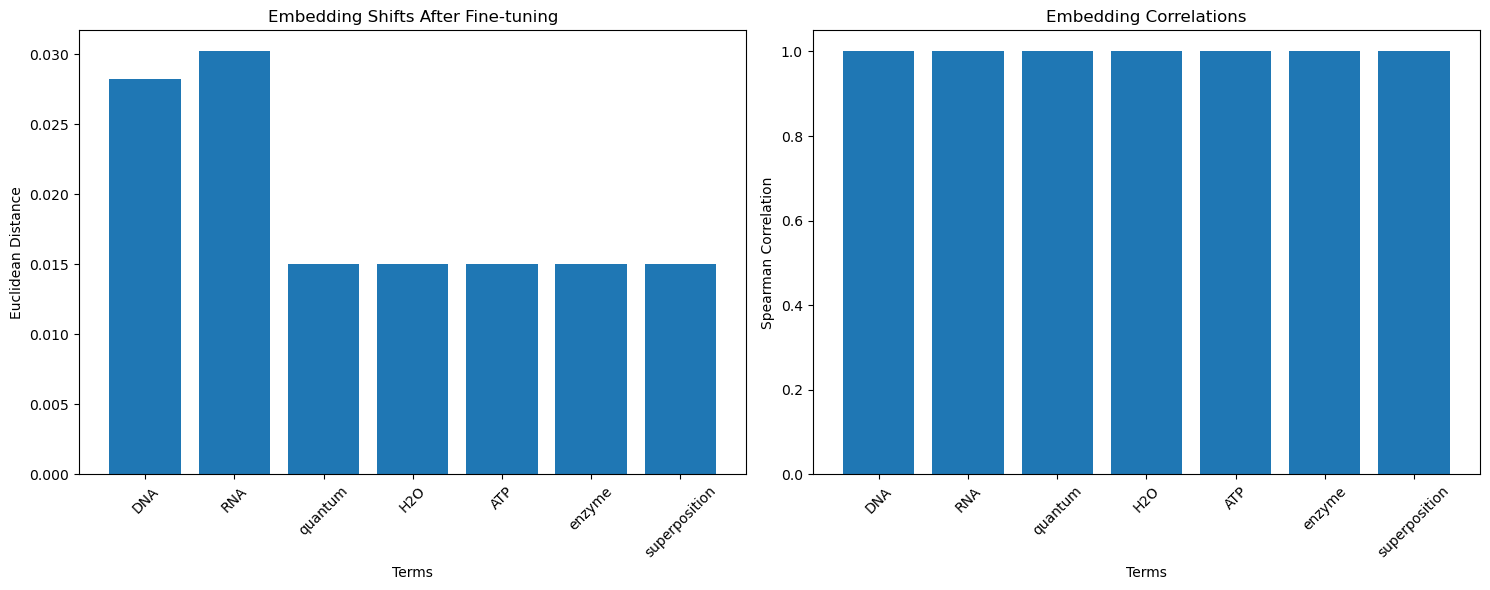


Model Comparison Summary:
Average Embedding Shift: 0.0191
Average Embedding Correlation: 1.0000


In [6]:
# Cell 6: Comparative Analysis with Base Model
def compare_with_base_model(model_path, terms):
    """
    Compare embeddings between base and fine-tuned models
    """
    base_model = GPT2LMHeadModel.from_pretrained("distilgpt2")
    fine_tuned_model = GPT2LMHeadModel.from_pretrained(model_path)
    tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
    
    base_embeddings = base_model.transformer.wte.weight.detach().cpu().numpy()
    fine_tuned_embeddings = fine_tuned_model.transformer.wte.weight.detach().cpu().numpy()
    
    term_ids = [tokenizer.convert_tokens_to_ids(term) for term in terms 
                if tokenizer.convert_tokens_to_ids(term) is not None]
    
    base_selected = base_embeddings[term_ids]
    fine_tuned_selected = fine_tuned_embeddings[term_ids]
    
    # Calculate embedding shifts
    shifts = np.linalg.norm(fine_tuned_selected - base_selected, axis=1)
    correlations = [spearmanr(base, fine)[0] for base, fine 
                   in zip(base_selected, fine_tuned_selected)]
    
    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot embedding shifts
    ax1.bar(terms, shifts)
    ax1.set_title('Embedding Shifts After Fine-tuning')
    ax1.set_xlabel('Terms')
    ax1.set_ylabel('Euclidean Distance')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
    
    # Plot correlations
    ax2.bar(terms, correlations)
    ax2.set_title('Embedding Correlations')
    ax2.set_xlabel('Terms')
    ax2.set_ylabel('Spearman Correlation')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nModel Comparison Summary:")
    print(f"Average Embedding Shift: {np.mean(shifts):.4f}")
    print(f"Average Embedding Correlation: {np.mean(correlations):.4f}")
    
    return shifts, correlations

# Compare models
embedding_shifts, embedding_correlations = compare_with_base_model(MODEL_PATH, scientific_terms)


Domain-Specific Response Quality Analysis:
Average sentences per response: 3.33
Question repetition rate: 100.0%
Scientific terms usage rate: 100.0%
URL/Reference inclusion rate: 0.0%
Incomplete response rate: 0.0%
Response length variance: 2573.56


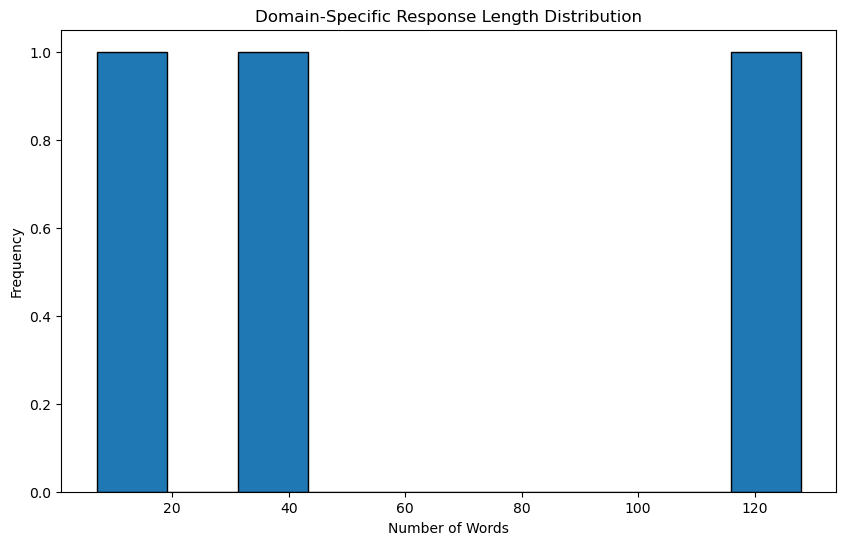


General Response Quality Analysis:
Average sentences per response: 3.00
Question repetition rate: 100.0%
Scientific terms usage rate: 33.3%
URL/Reference inclusion rate: 33.3%
Incomplete response rate: 100.0%
Response length variance: 470.89


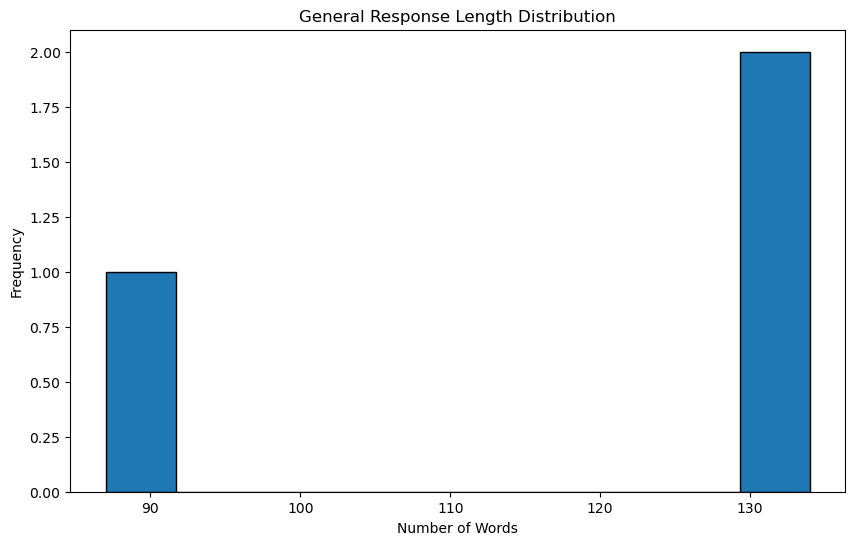


Comparison of Domain-Specific vs General Responses:
                       Domain-Specific  General
avg_sentences                     3.33     3.00
question_repeat_rate            100.00   100.00
scientific_terms_rate           100.00    33.33
url_reference_rate                0.00    33.33
incomplete_rate                   0.00   100.00
length_variance                2573.56   470.89


<Figure size 1200x600 with 0 Axes>

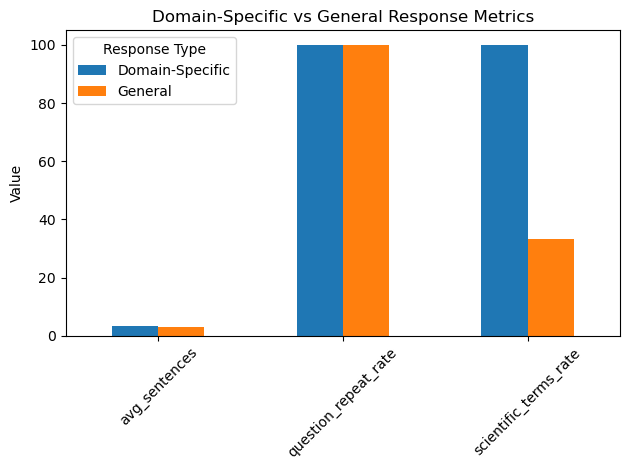

In [7]:
# Cell 7: Enhanced Response Quality Analysis
def analyze_response_quality(responses, category):
    """
    Analyze the quality of model responses with enhanced metrics
    """
    # Initialize quality metrics
    metrics = {
        'question_repeat': 0,
        'response_length': [],
        'sentence_count': [],
        'scientific_terms_used': 0,
        'url_or_references': 0,
        'incomplete_sentences': 0
    }
    
    # Scientific terms to look for (expand this list based on your domain)
    scientific_terms = set(['quantum', 'molecule', 'electron', 'proton', 'energy', 
                          'particle', 'catalyst', 'reaction', 'neural', 'algorithm'])
    
    for response in responses:
        text = response['response']
        prompt = response['prompt']
        
        # Check if response repeats the question
        if text.startswith(prompt):
            metrics['question_repeat'] += 1
        
        # Count sentences (roughly)
        sentences = [s.strip() for s in text.split('.') if s.strip()]
        metrics['sentence_count'].append(len(sentences))
        
        # Check for scientific terms
        words = set(text.lower().split())
        if any(term in words for term in scientific_terms):
            metrics['scientific_terms_used'] += 1
            
        # Check for URLs or references
        if 'http' in text or '[' in text:
            metrics['url_or_references'] += 1
            
        # Check for incomplete sentences
        if text.strip()[-1] not in '.!?':
            metrics['incomplete_sentences'] += 1
        
        metrics['response_length'].append(len(text.split()))
    
    # Calculate averages and percentages
    total_responses = len(responses)
    quality_summary = {
        'avg_sentences': np.mean(metrics['sentence_count']),
        'question_repeat_rate': metrics['question_repeat'] / total_responses * 100,
        'scientific_terms_rate': metrics['scientific_terms_used'] / total_responses * 100,
        'url_reference_rate': metrics['url_or_references'] / total_responses * 100,
        'incomplete_rate': metrics['incomplete_sentences'] / total_responses * 100,
        'length_variance': np.var(metrics['response_length'])
    }
    
    # Print analysis
    print(f"\n{category} Response Quality Analysis:")
    print(f"Average sentences per response: {quality_summary['avg_sentences']:.2f}")
    print(f"Question repetition rate: {quality_summary['question_repeat_rate']:.1f}%")
    print(f"Scientific terms usage rate: {quality_summary['scientific_terms_rate']:.1f}%")
    print(f"URL/Reference inclusion rate: {quality_summary['url_reference_rate']:.1f}%")
    print(f"Incomplete response rate: {quality_summary['incomplete_rate']:.1f}%")
    print(f"Response length variance: {quality_summary['length_variance']:.2f}")
    
    # Visualize length distribution
    plt.figure(figsize=(10, 6))
    plt.hist(metrics['response_length'], bins=10, edgecolor='black')
    plt.title(f'{category} Response Length Distribution')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.show()
    
    return quality_summary

# Analyze quality for both sets of responses
domain_quality = analyze_response_quality(domain_responses, "Domain-Specific")
general_quality = analyze_response_quality(general_responses, "General")

# Compare domain-specific vs general performance
comparison_metrics = pd.DataFrame({
    'Domain-Specific': domain_quality,
    'General': general_quality
}).round(2)

print("\nComparison of Domain-Specific vs General Responses:")
print(comparison_metrics)

# Visualize comparison
plt.figure(figsize=(12, 6))
metrics_to_plot = ['avg_sentences', 'question_repeat_rate', 'scientific_terms_rate']
comparison_metrics.loc[metrics_to_plot].plot(kind='bar')
plt.title('Domain-Specific vs General Response Metrics')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(title='Response Type')
plt.tight_layout()
plt.show()